In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import csv
import os

june_july_dataset_path = 'data/June and July dataset/'
jan_feb_dataset_path = 'data/January_February_dataset/'

In [7]:
# Load the data
viewers_by_fetch_part1 = pd.read_json(june_july_dataset_path + 'Viewers_by_fetch_part1.json', lines=True, dtype={'video': 'object', 'viewers_count': 'int32'})
viewers_by_fetch_part2 = pd.read_json(june_july_dataset_path + 'viewers_by_fetch_part2.json', lines=True, dtype={'video': 'object', 'viewers_count': 'int32'})
jan_viewers_by_fetch = pd.read_json(jan_feb_dataset_path + 'viewers_by_fetch_period1and2.json', lines=True, dtype={'video': 'object', 'viewers_count': 'int32'})
viewers_by_fetch = pd.concat([viewers_by_fetch_part1, viewers_by_fetch_part2, jan_viewers_by_fetch], ignore_index=True)
del viewers_by_fetch_part1, viewers_by_fetch_part2, jan_viewers_by_fetch

# Convert 'video' column
viewers_by_fetch["video"] = viewers_by_fetch["video"].apply(lambda x: x['$oid'] if isinstance(x, dict) else x)

# Convert 'refresh_time' column to datetime
viewers_by_fetch["refresh_time"] = pd.to_datetime(viewers_by_fetch["refresh_time"])

# Optimize memory usage
viewers_by_fetch['viewers_count'] = pd.to_numeric(viewers_by_fetch['viewers_count'], downcast='unsigned')
viewers_by_fetch['_id'] = viewers_by_fetch['_id'].apply(lambda x: x['$oid'] if isinstance(x, dict) else x)

In [8]:
min_viewers_threshold = 1000
max_thresholds = [5000, 10000, float('inf')]
max_viewers = viewers_by_fetch.groupby('video')['viewers_count'].max()
videos_with_high_viewers_total = max_viewers[max_viewers >= min_viewers_threshold].index
videos_with_high_viewers_small = max_viewers[(max_viewers >= min_viewers_threshold) & (max_viewers < max_thresholds[0])].index
videos_with_high_viewers_medium = max_viewers[(max_viewers >= max_thresholds[0]) & (max_viewers < max_thresholds[1])].index
videos_with_high_viewers_big = max_viewers[max_viewers >= max_thresholds[1]].index
display(len(videos_with_high_viewers_total), len(videos_with_high_viewers_small), len(videos_with_high_viewers_medium), len(videos_with_high_viewers_big))
videos_with_high_viewers_total = viewers_by_fetch[viewers_by_fetch['video'].isin(videos_with_high_viewers_total)]
videos_with_high_viewers_small = viewers_by_fetch[viewers_by_fetch['video'].isin(videos_with_high_viewers_small)]
videos_with_high_viewers_medium = viewers_by_fetch[viewers_by_fetch['video'].isin(videos_with_high_viewers_medium)]
videos_with_high_viewers_big = viewers_by_fetch[viewers_by_fetch['video'].isin(videos_with_high_viewers_big)]


29688

26985

1904

799

In [9]:
min_sampling_points = 10
video_row_counts = videos_with_high_viewers_total.groupby('video', observed=True).size()
video_row_counts = video_row_counts[video_row_counts >= min_sampling_points]
videos_with_high_viewers_total = videos_with_high_viewers_total[videos_with_high_viewers_total['video'].isin(video_row_counts.index)]
videos_with_high_viewers_small = videos_with_high_viewers_small[videos_with_high_viewers_small['video'].isin(video_row_counts.index)]
videos_with_high_viewers_medium = videos_with_high_viewers_medium[videos_with_high_viewers_medium['video'].isin(video_row_counts.index)]
videos_with_high_viewers_big = videos_with_high_viewers_big[videos_with_high_viewers_big['video'].isin(video_row_counts.index)]

In [10]:
video_row_counts = videos_with_high_viewers_total.groupby('video', observed=True).size()
video_row_counts = video_row_counts[video_row_counts > 1]
display(f"Avg. number of sampling points per video (total): {video_row_counts.mean()}")
display(f"Median number of sampling per video (total): {video_row_counts.median()}")
n_videos = len(video_row_counts)
display(f"Number of videos (total): {n_videos}")
video_row_counts_small = videos_with_high_viewers_small.groupby('video', observed=True).size()
video_row_counts_small = video_row_counts_small[video_row_counts_small > 1]
display(f"Avg. number of sampling points per video (small): {video_row_counts_small.mean()}")
display(f"Median number of sampling points per video (small): {video_row_counts_small.median()}")
n_videos = len(video_row_counts_small)
display(f"Number of videos (small): {n_videos}")
video_row_counts_med = videos_with_high_viewers_medium.groupby('video', observed=True).size()
video_row_counts_med = video_row_counts_med[video_row_counts_med > 1]
display(f"Avg. number of sampling points per video (medium): {video_row_counts_med.mean()}")
display(f"Median number of sampling points per video (medium): {video_row_counts_med.median()}")
n_videos = len(video_row_counts_med)
display(f"Number of videos (medium): {n_videos}")
video_row_counts_big = videos_with_high_viewers_big.groupby('video', observed=True).size()
video_row_counts_big = video_row_counts_big[video_row_counts_big > 1]
display(f"Avg. number of sampling points per video (big): {video_row_counts_big.mean()}")
display(f"Median number of sampling points per video (big): {video_row_counts_big.median()}")
n_videos = len(video_row_counts_big)
display(f"Number of videos (big): {n_videos}")

'Avg. number of sampling points per video (total): 18.308055380742605'

'Median number of sampling per video (total): 16.0'

'Number of videos (total): 6356'

'Avg. number of sampling points per video (small): 18.289007397213144'

'Median number of sampling points per video (small): 15.0'

...

'Median number of sampling points per video (medium): 16.0'

'Number of videos (medium): 422'

'Avg. number of sampling points per video (big): 19.041322314049587'

'Median number of sampling points per video (big): 17.0'

'Number of videos (big): 121'

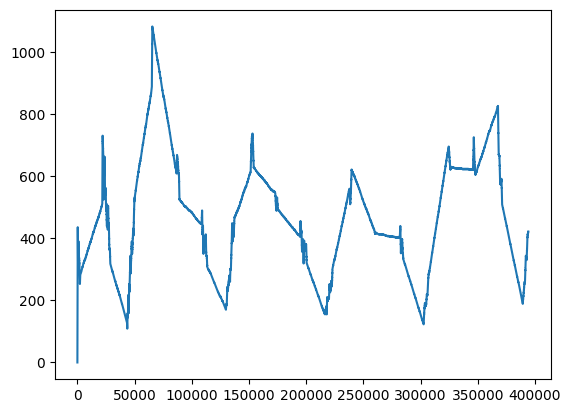

In [31]:
def plot_user_events(filepath):
    user_events = pd.read_csv(filepath)

    user_events['y'] = user_events['event'].apply(lambda x: 1 if x == 1 else -1 if x == 3 else 0).cumsum()
    fig, ax = plt.subplots()
    ax.plot(user_events['timestamp'], user_events['y'])
    # ax.set_xticks(user_events['timestamp'][::len(user_events)//10])
    # ax.set_xticklabels(user_events['timestamp'][::len(user_events)//10], rotation=90)

plot_user_events('sessions/session-small/session-small-1692.csv')

In [7]:
def plot_instance(file, figtitle):
    instance = pd.read_csv(file)
    viewer_count_array = []
    viewer_count = 0
    viewer_count_session = {}
    timestamps = []
    timestamps_sessions = [0]
    sessions = [0]
    for _, row in instance.iterrows():
        repeat = row["repeat"]
        if row["event"] == 0:
            session = row["id"]
            session = f"{session}-{repeat}"
            viewer_count_session[session] = {
                "viewer_count": 0,
                "viewer_count_array": [0],
                "timestamps": [row["timestamp"]]
            }
            sessions.append(sessions[-1] + 1)
            timestamps_sessions.append(row["timestamp"])
        elif row["event"] == 2:
            session = row["id"]
            session = f"{session}-{repeat}"
            viewer_count -= viewer_count_session[session]["viewer_count"]
            sessions.append(sessions[-1] - 1)
            timestamps_sessions.append(row["timestamp"])
        elif row["event"] == 1:
            session = '-'.join(row["id"].split("-")[:-1])
            session = f"{session}-{repeat}"
            viewer_count_session[session]["viewer_count"] += 1
            viewer_count_session[session]["viewer_count_array"].append(viewer_count_session[session]["viewer_count"])
            viewer_count_session[session]["timestamps"].append(row["timestamp"])
            viewer_count += 1
        elif row["event"] == 3:
            session = '-'.join(row["id"].split("-")[:-1])
            session = f"{session}-{repeat}"
            viewer_count_session[session]["viewer_count"] -= 1
            viewer_count_session[session]["viewer_count_array"].append(viewer_count_session[session]["viewer_count"])
            viewer_count_session[session]["timestamps"].append(row["timestamp"])
            viewer_count -= 1
        viewer_count_array.append(viewer_count)
        timestamps.append(row["timestamp"])
    fig, ax = plt.subplots(figsize=(15, 7))
    ax.plot(timestamps, viewer_count_array, 'b--', label="Total viewers")
    for session in viewer_count_session:
        session_label = '-'.join(session.split("-")[:-2])
        ax.plot(viewer_count_session[session]["timestamps"], viewer_count_session[session]["viewer_count_array"])
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Number of viewers")
    ax2 = ax.twinx()
    ax2.plot(timestamps_sessions, sessions, 'r--', label="Total sessions")
    ax2.set_ylabel("Number of sessions")
    fig.legend()
    ax.grid()
    fig.suptitle(figtitle)



C:\Users\millenium\AppData\Local\Temp\ipykernel_55972\3696434792.py:43: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(15, 7))


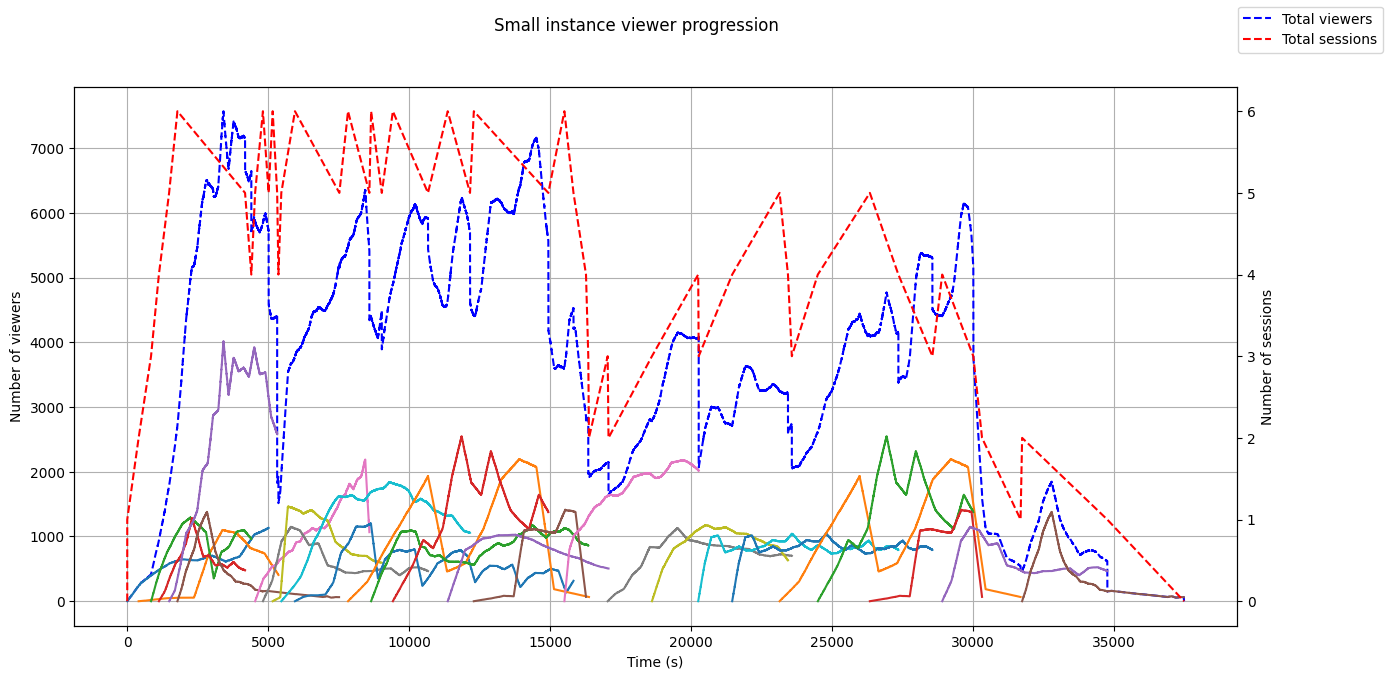

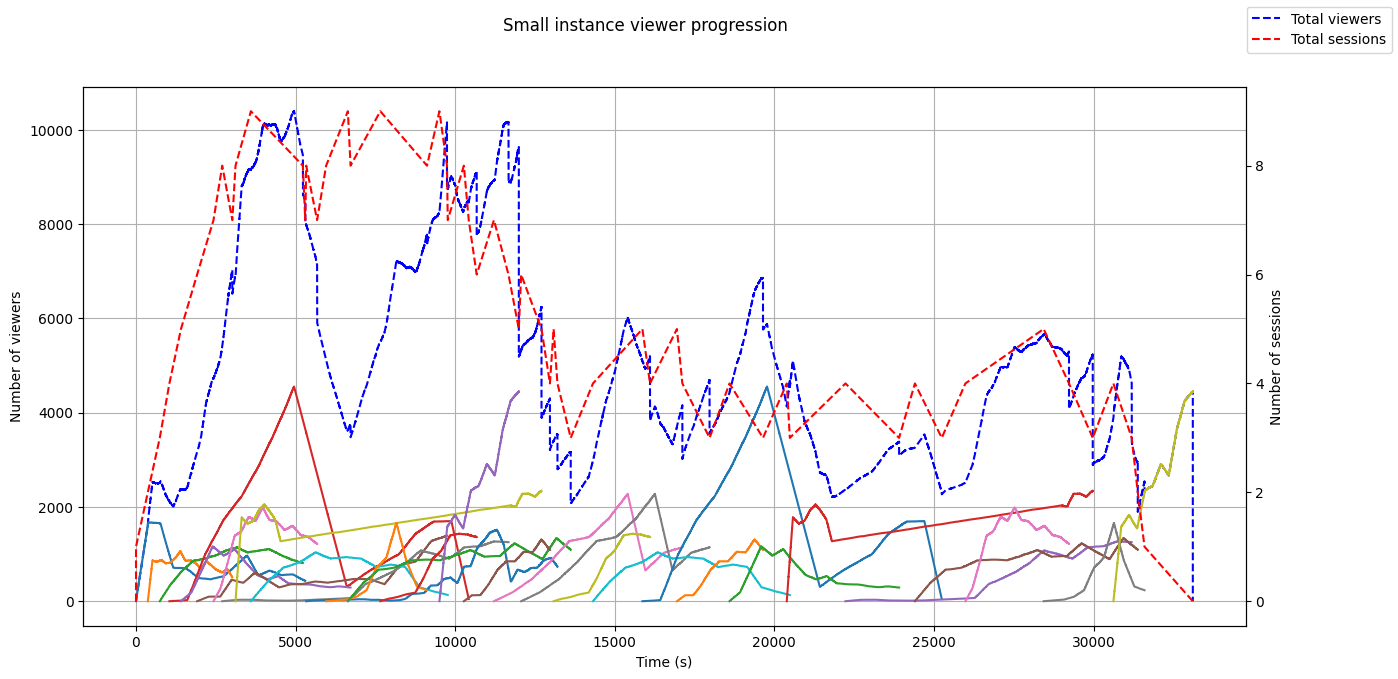

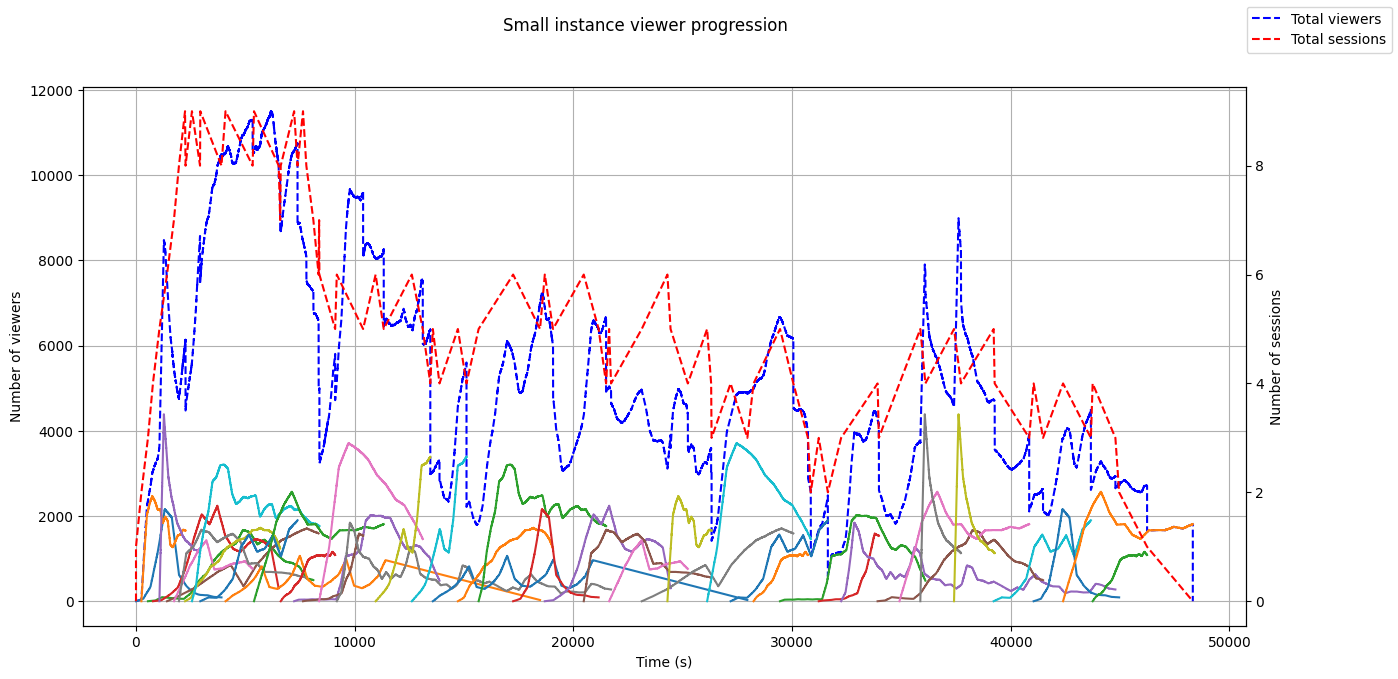

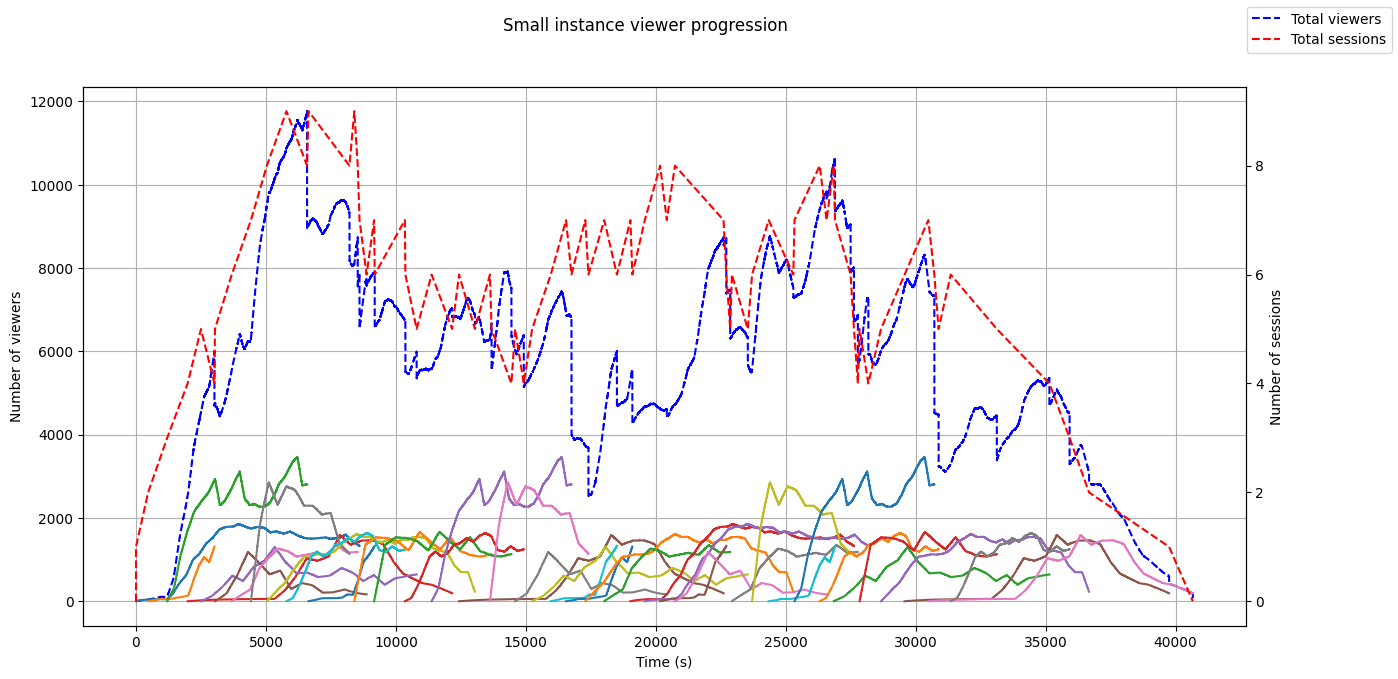

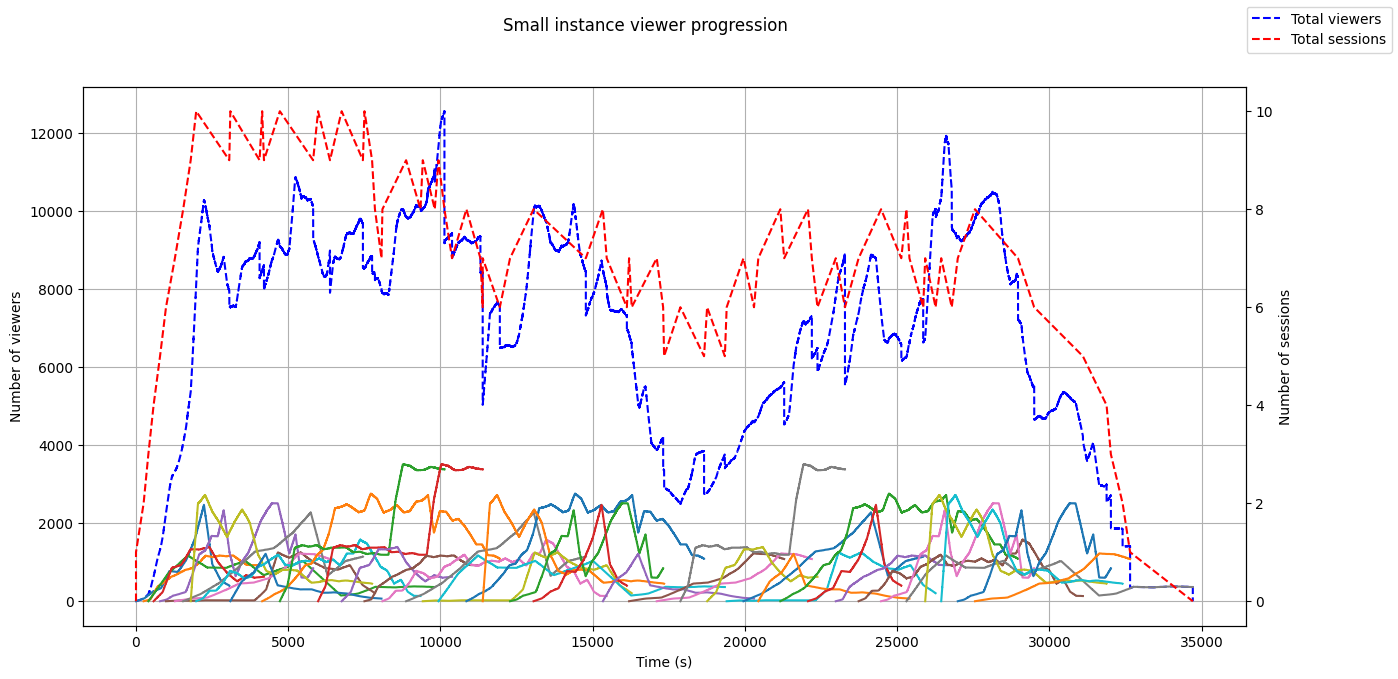

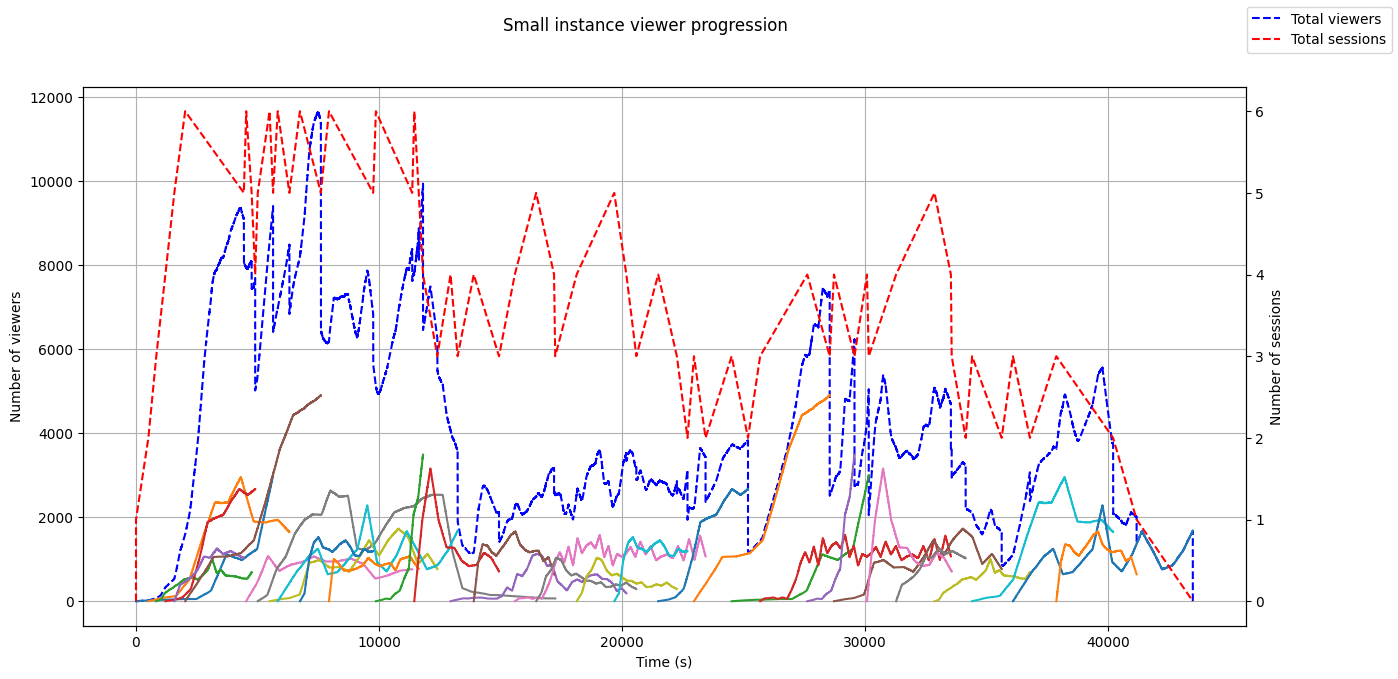

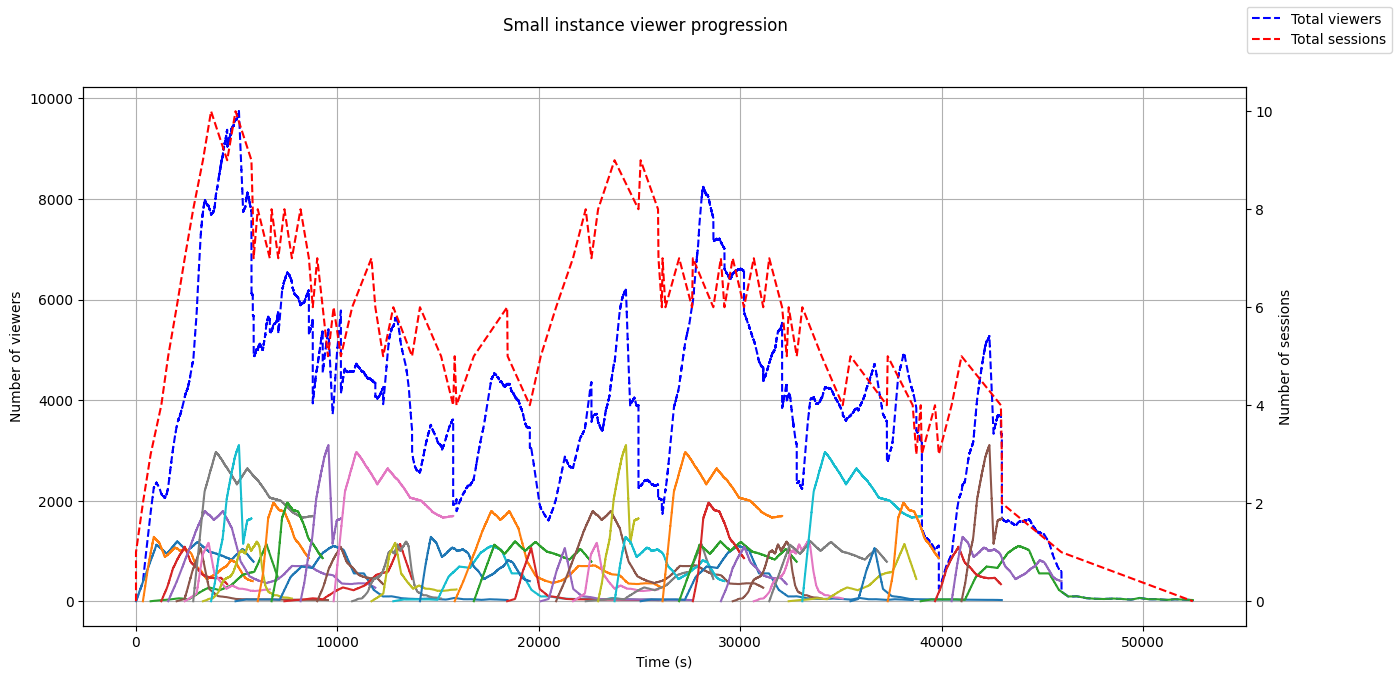

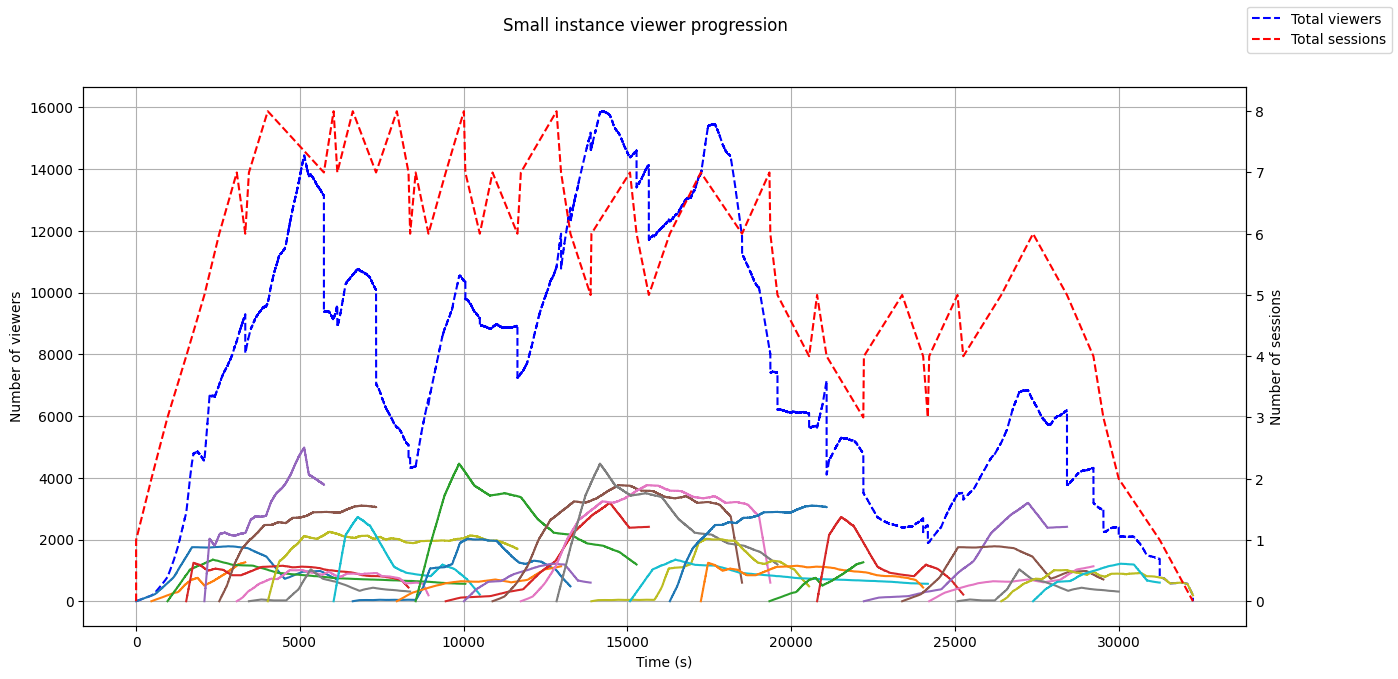

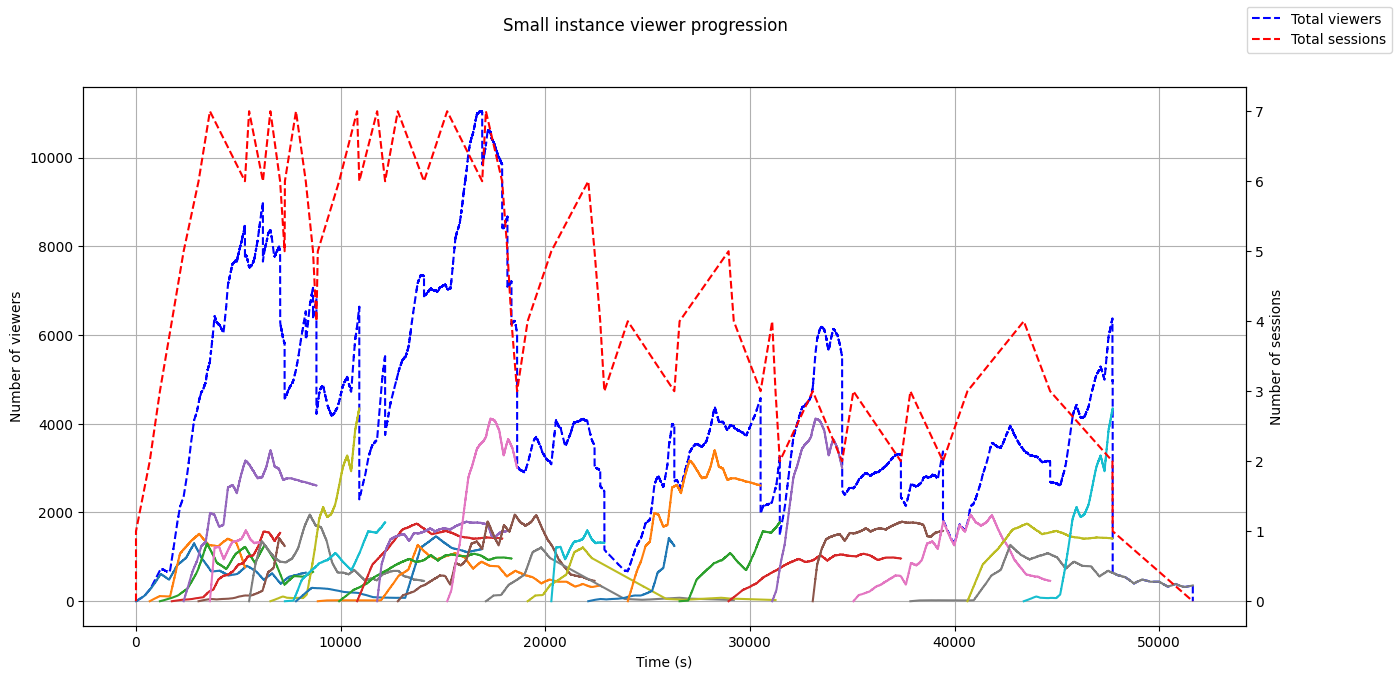

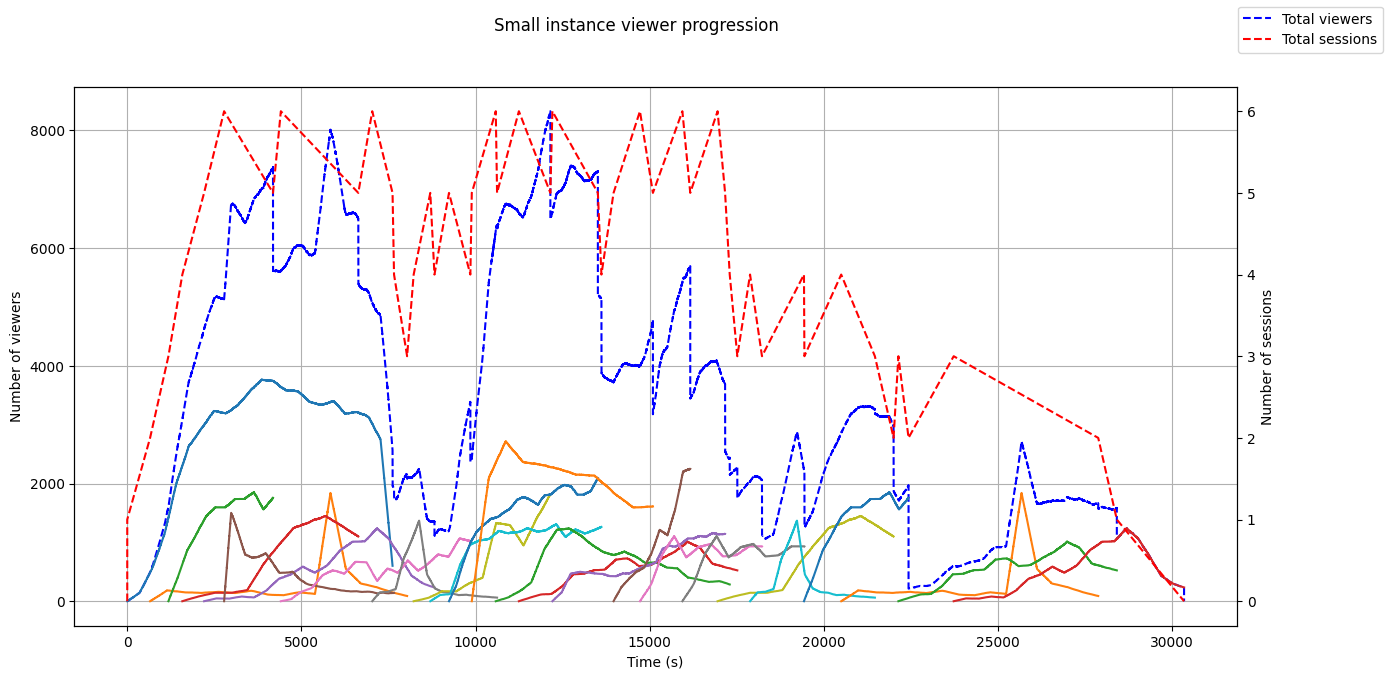

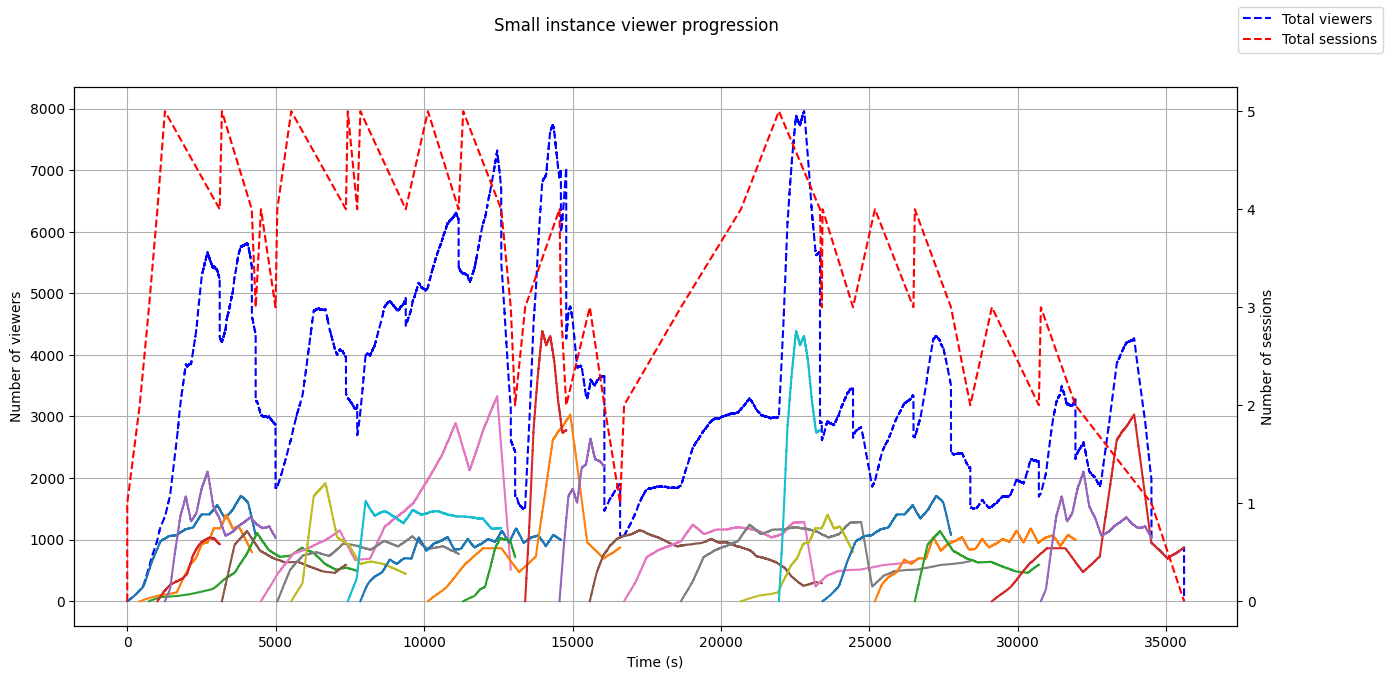

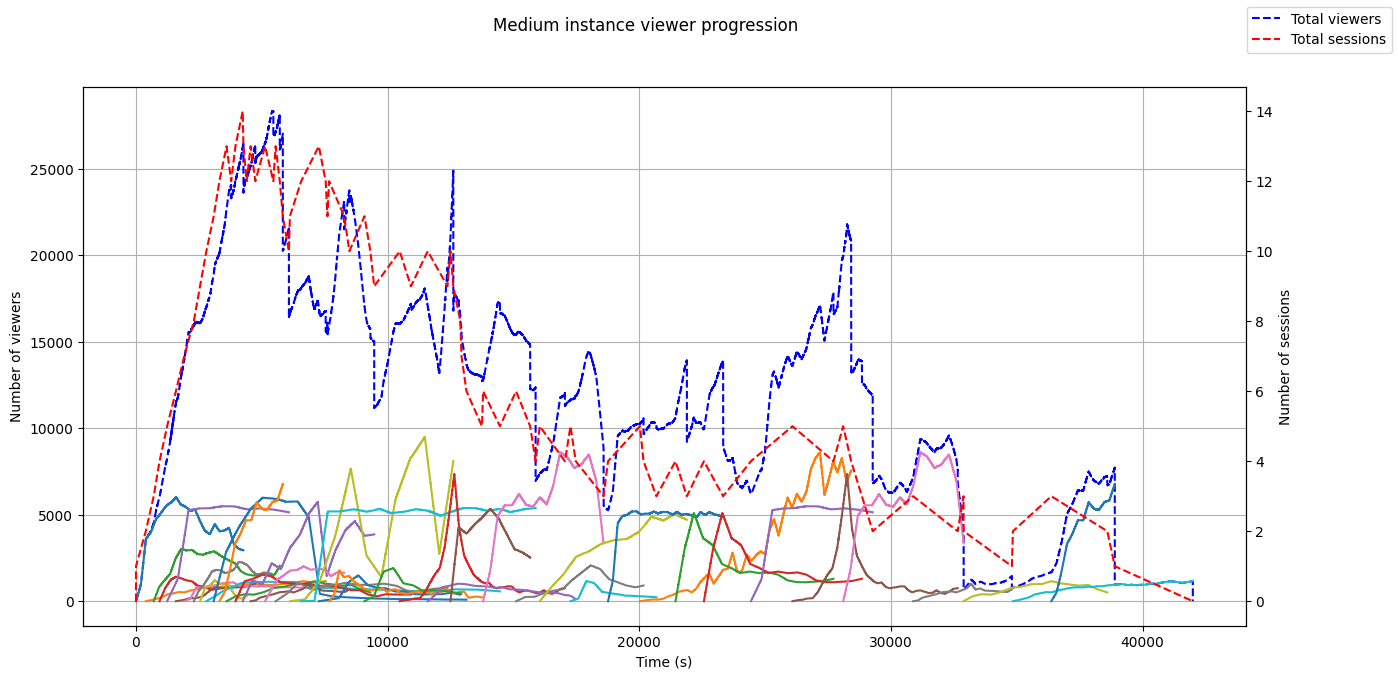

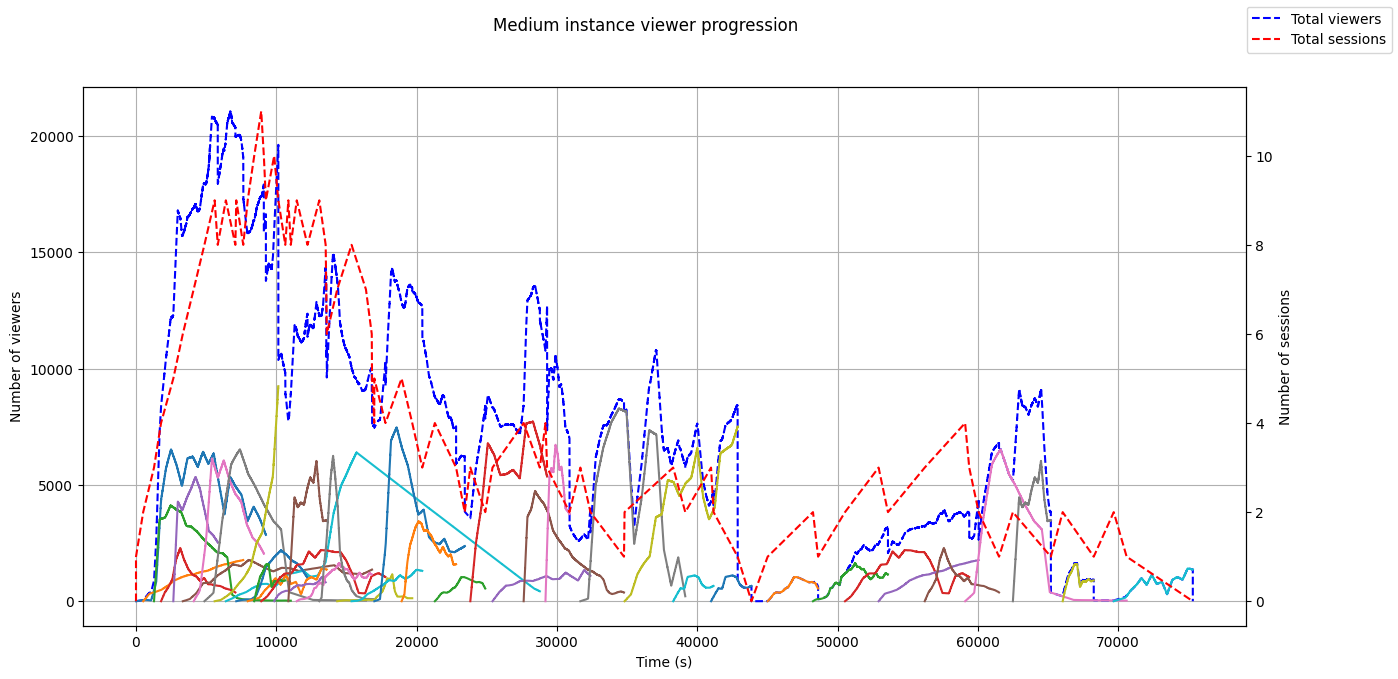

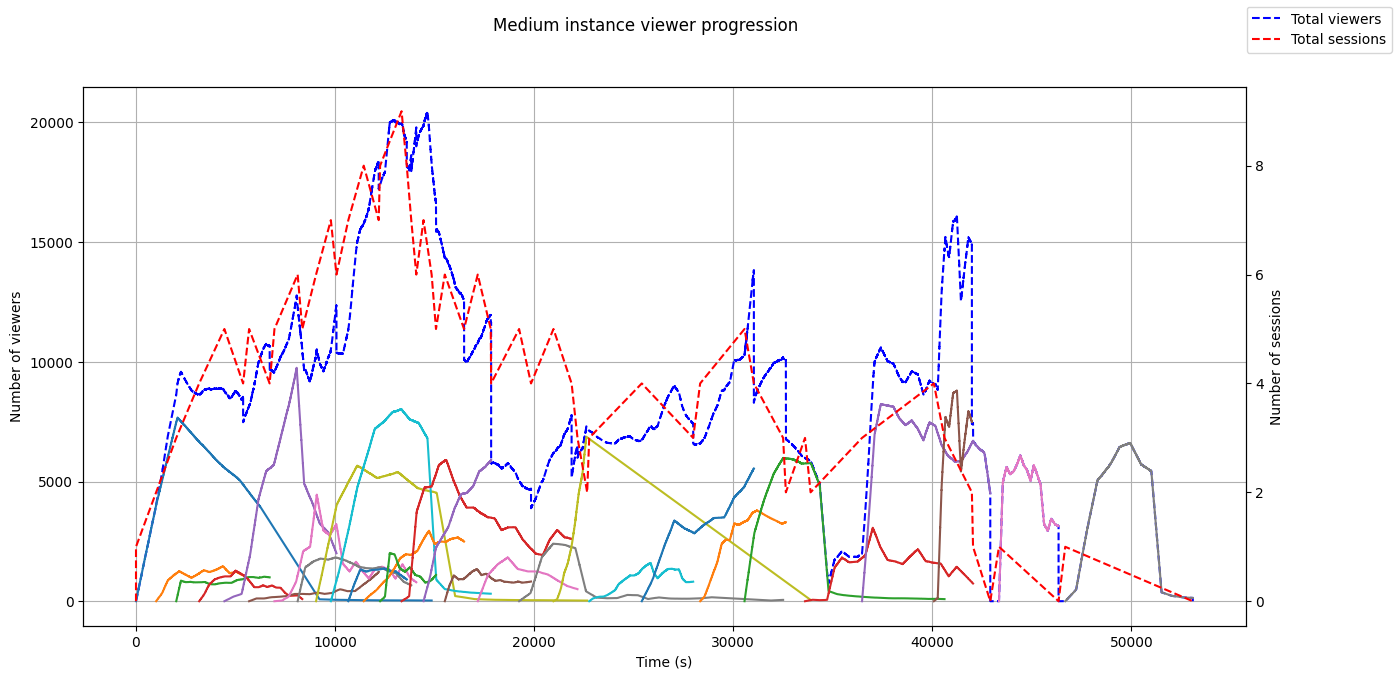

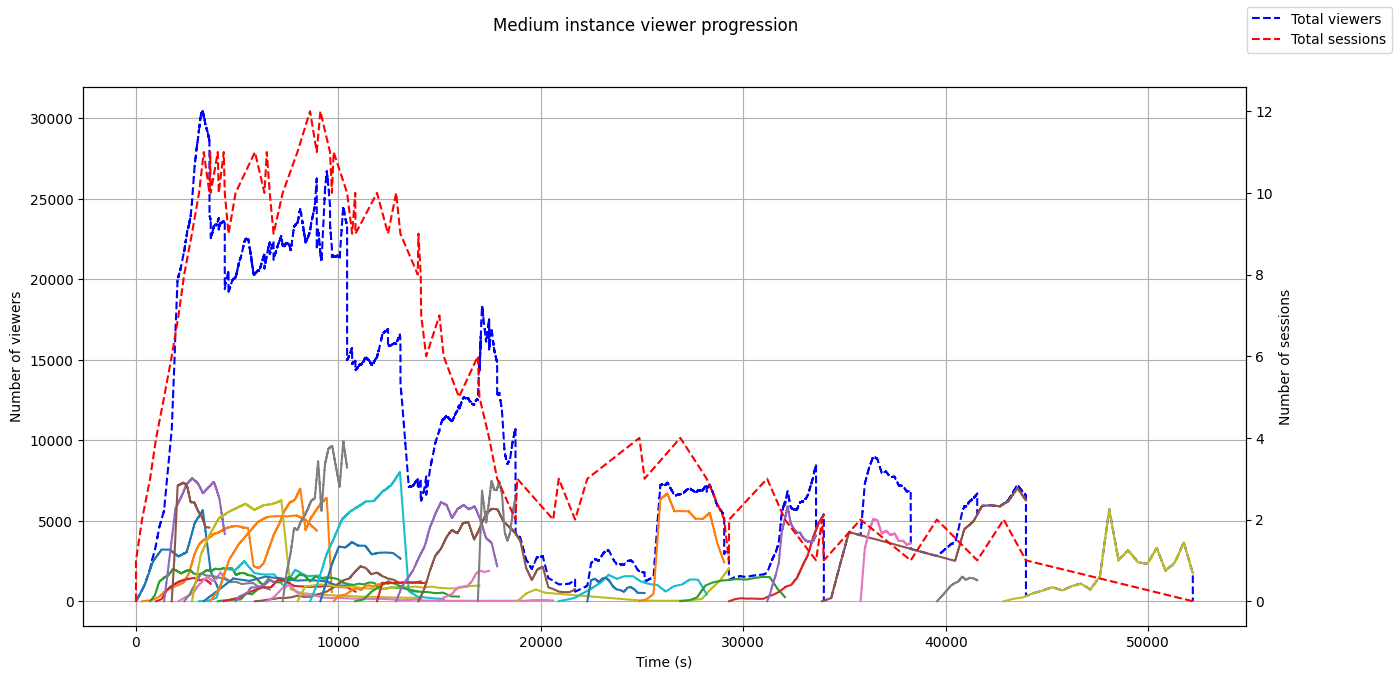

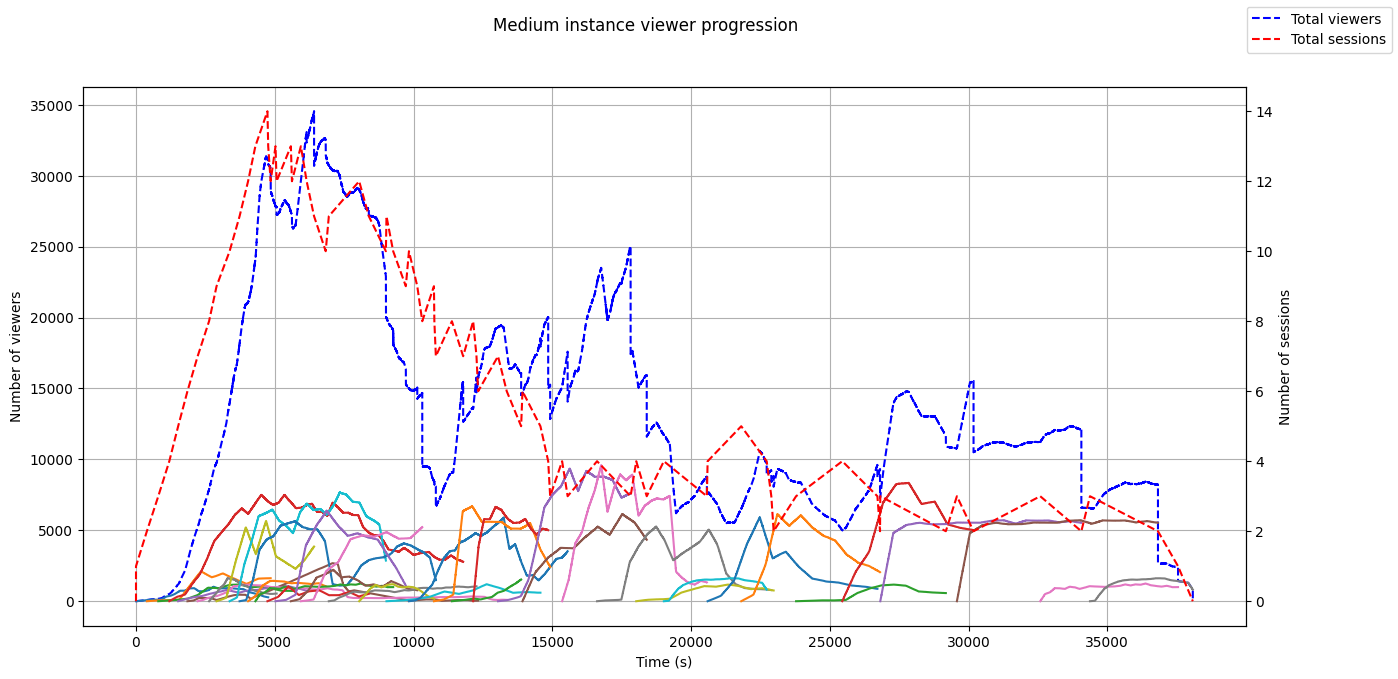

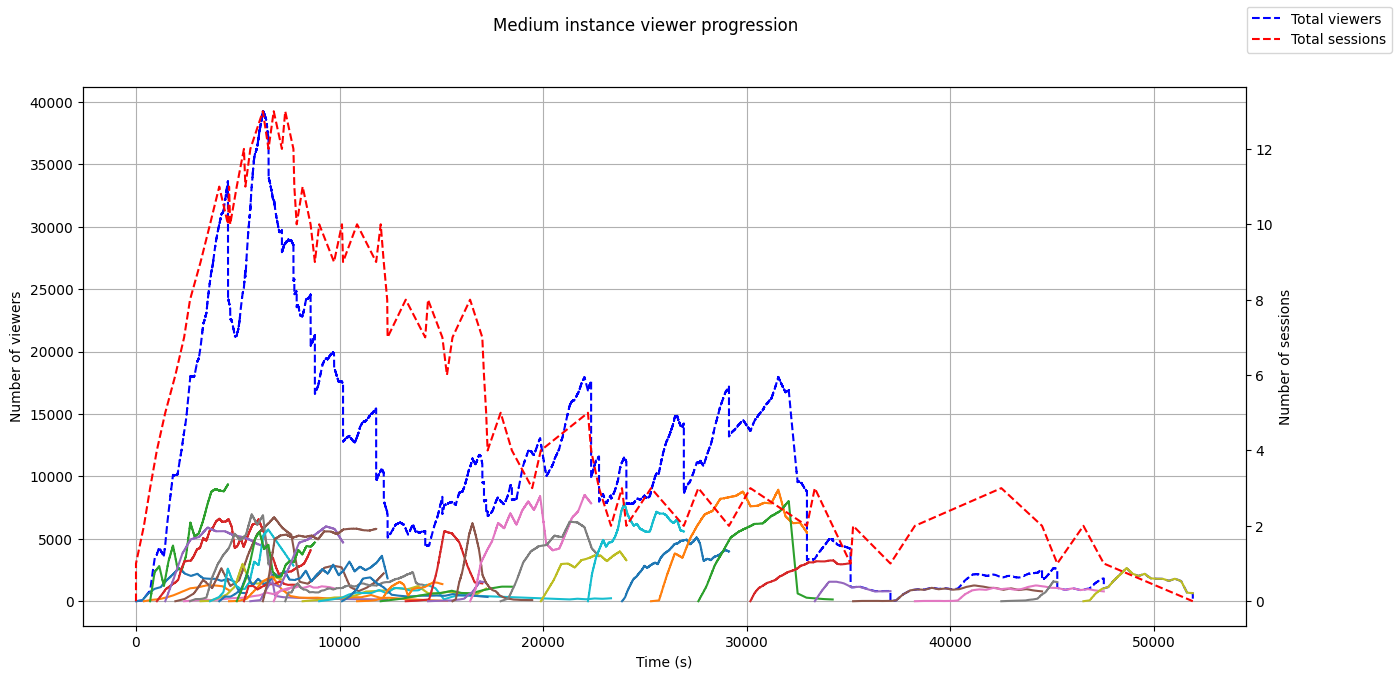

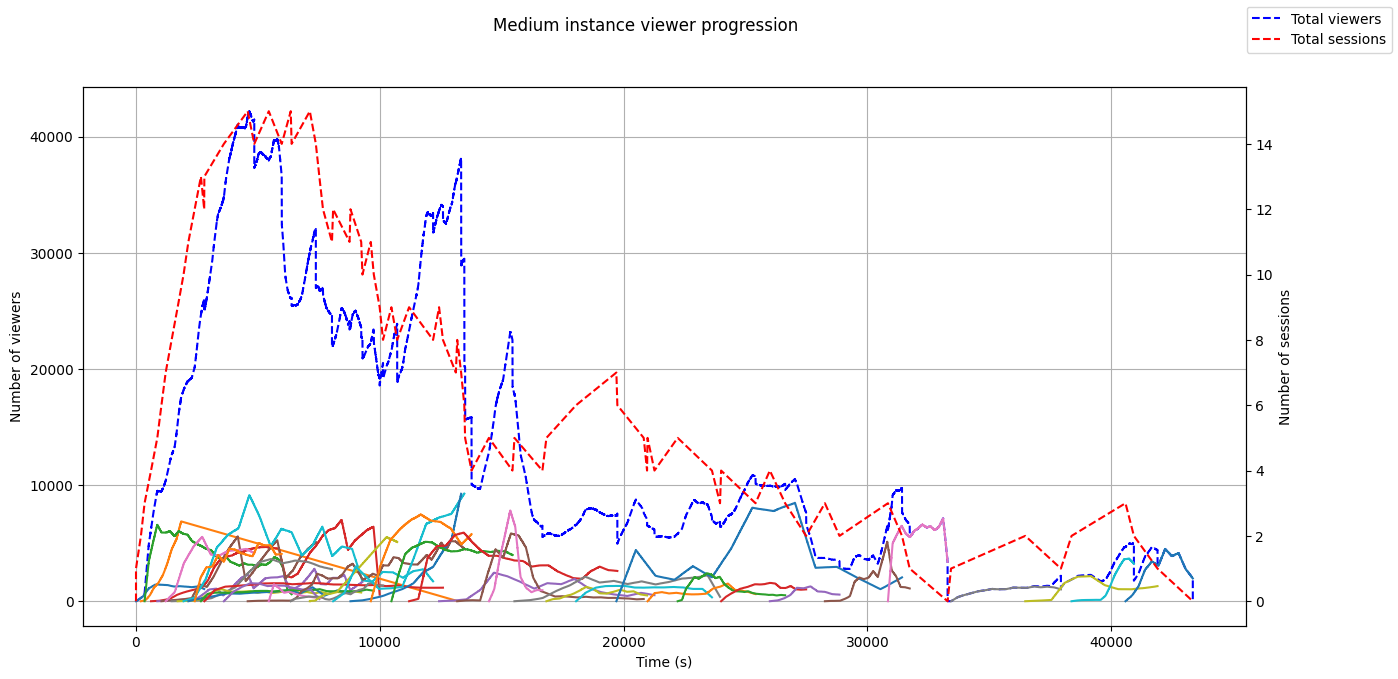

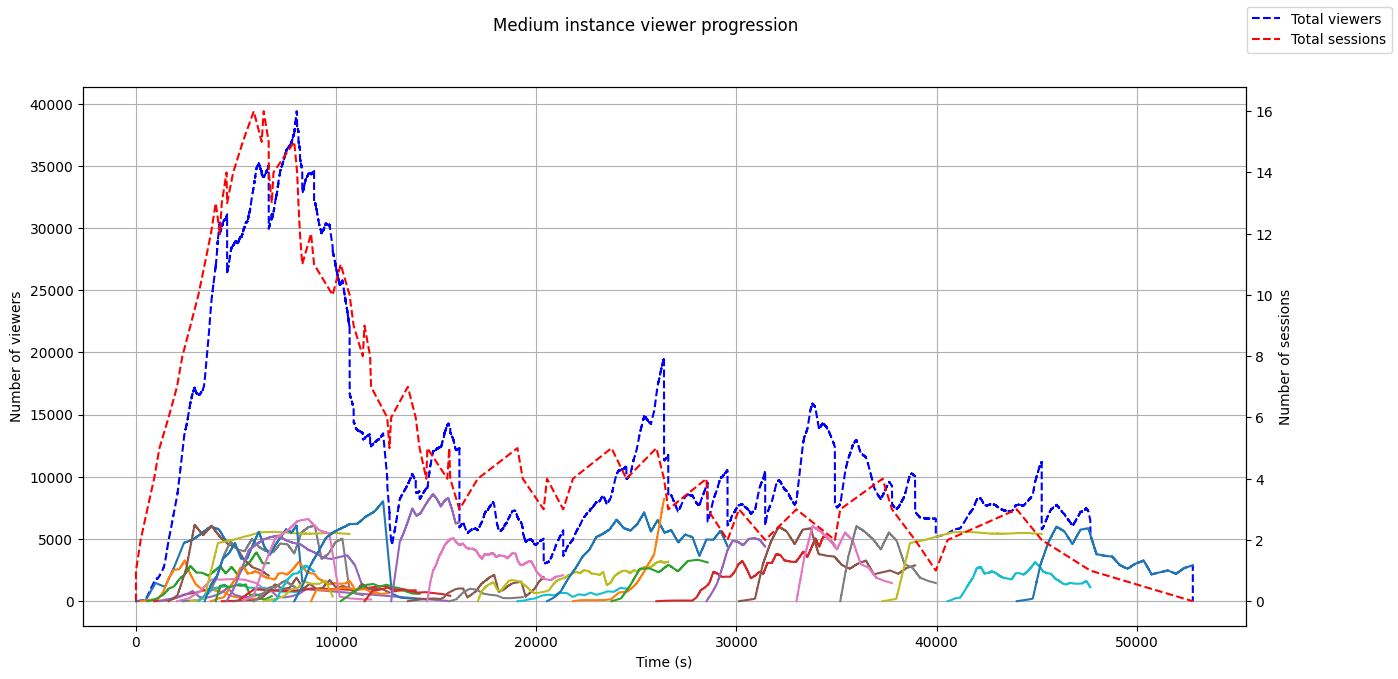

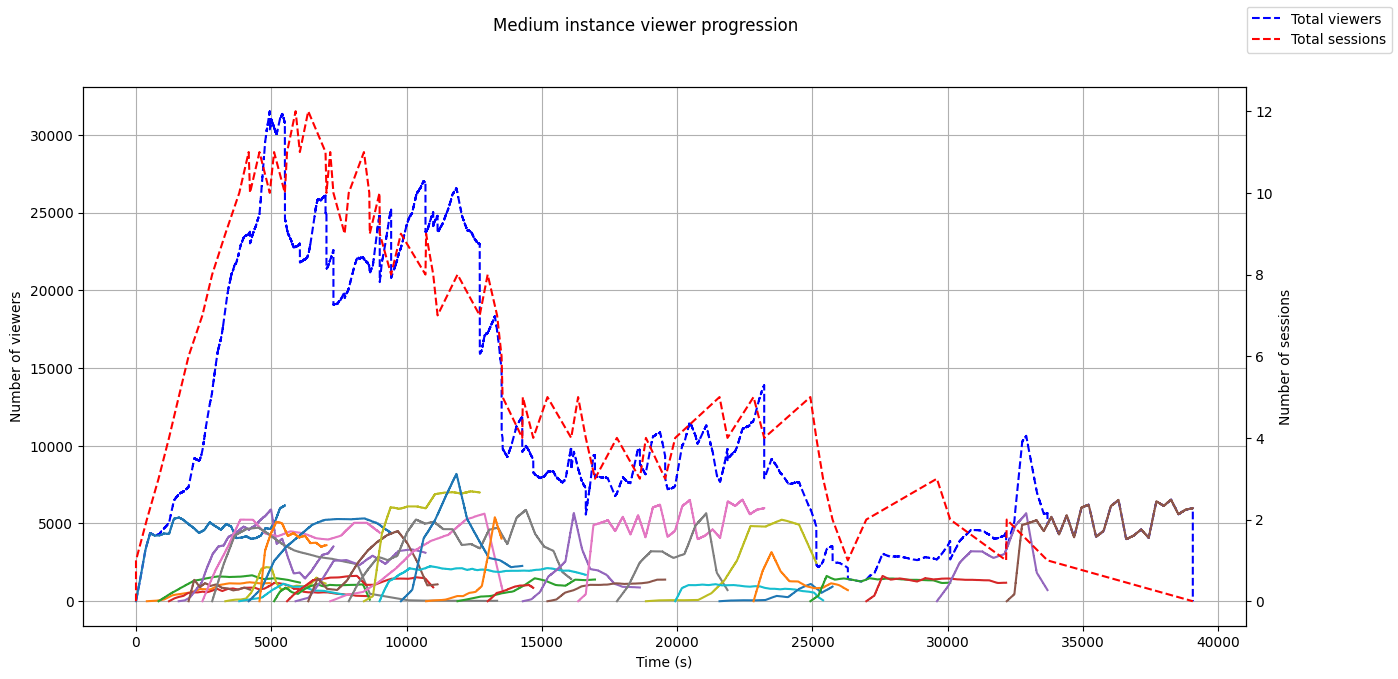

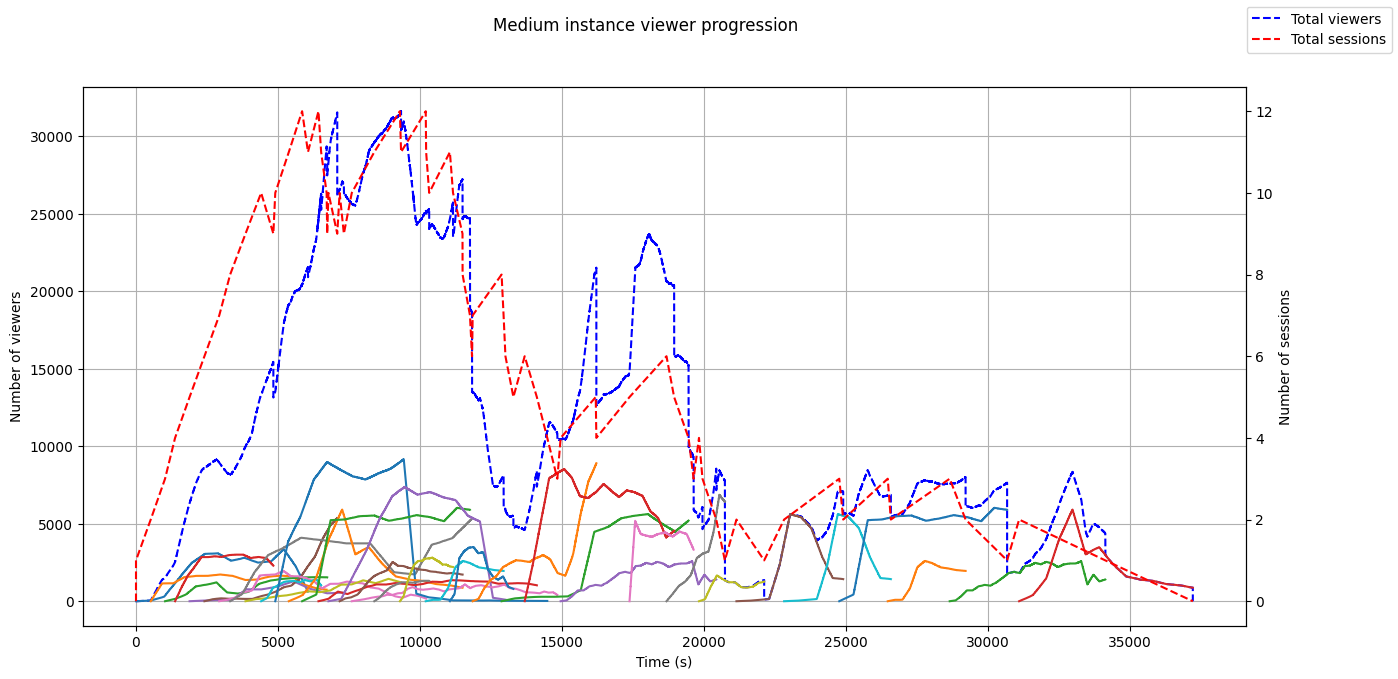

In [9]:
for i in range(11):
    plot_instance(f'instances/instances-small/instance-small-{i}.csv', "Small instance viewer progression")
for i in range(10):
    plot_instance(f'instances/instances-medium/instance-medium-{i}.csv', "Medium instance viewer progression")
#plot_instance('instances/instances-big/instance-big-1.csv', "Big instance viewer progression")